## Model Training and Validation

This and the next notebook trains baseline and ensemble models to predict
customer default risk using engineered features.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Credit_Risk_Project/data/behavioral_features.csv"
df = pd.read_csv(path)
df.shape

(30000, 31)

In [ ]:
df = df.apply(pd.to_numeric)
df.dtypes

,0
ID,int64
LIMIT_BAL,int64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64


In [ ]:
df.shape
df['default'].value_counts(normalize=True)

,proportion
default,
0,0.7788
1,0.2212


In [ ]:
target = 'default'

features = [
    col for col in df.columns
    if col not in ['ID', target]
]

X = df[features]
y = df[target]

X.shape, y.shape

((30000, 29), (30000,))

In [ ]:
# --------------------------------------------
# Holdout Validation Split
# --------------------------------------------

# Sort by repayment severity to create a stable validation set
df_sorted = df.sort_values(by='PAY_0')

X_sorted = df_sorted[features]
y_sorted = df_sorted[target]

split_index = int(0.75 * len(df_sorted))

X_train = X_sorted.iloc[:split_index]
y_train = y_sorted.iloc[:split_index]

X_val = X_sorted.iloc[split_index:]
y_val = y_sorted.iloc[split_index:]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (22500, 29)
Validation size: (7500, 29)


### Baseline Model: Logistic Regression

Logistic Regression is used as an interpretable baseline model.


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import roc_auc_score

log_val_probs = log_model.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, log_val_probs)

np.float64(0.6208038538739462)

### Non-Linear Model: Random Forest

Random Forest captures non-linear patterns and interactions
in customer behavior.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=50, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [ ]:
rf_val_probs = rf_model.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, rf_val_probs)

np.float64(0.6592397519960747)

XGBoost Classifier

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_val_probs = xgb_model.predict_proba(X_val)[:,1]

from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(
    y_val,
    xgb_val_probs
)

print("XGBoost AUC:", xgb_auc)

XGBoost AUC: 0.624192194121058


Comparison between different classifiers

In [ ]:
print("Logistic AUC:", roc_auc_score(y_val, log_val_probs))
print("RF AUC:", roc_auc_score(y_val, rf_val_probs))
print("XGB AUC:", xgb_auc)

Logistic AUC: 0.6208038538739462
RF AUC: 0.6592397519960747
XGB AUC: 0.624192194121058


Optimal Threshold: 0.10898989898989898
Minimum Cost: 38080


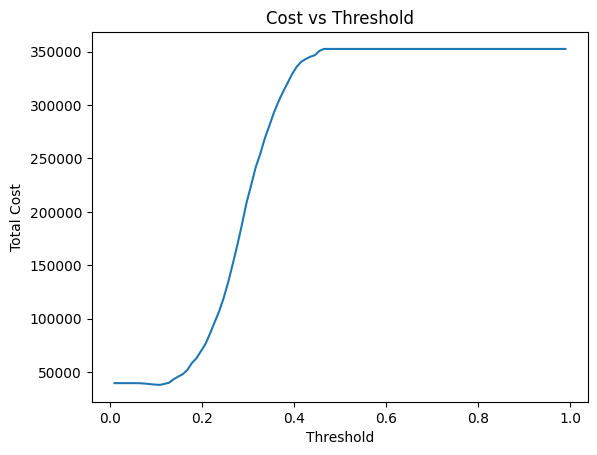

In [ ]:
# --------------------------------------------
# Threshold Optimization (Cost-Based)
# --------------------------------------------

cost_fn = 100   # Missed default
cost_fp = 10    # False alarm

thresholds = np.linspace(0.01, 0.99, 100)
costs = []

for t in thresholds:
    preds = (rf_val_probs >= t).astype(int)

    fn = ((preds == 0) & (y_val == 1)).sum()
    fp = ((preds == 1) & (y_val == 0)).sum()

    total_cost = fn * cost_fn + fp * cost_fp
    costs.append(total_cost)

optimal_threshold = thresholds[np.argmin(costs)]

print("Optimal Threshold:", optimal_threshold)
print("Minimum Cost:", min(costs))

plt.figure()
plt.plot(thresholds, costs)
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Cost vs Threshold")
plt.show()

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance.head(10)

,0
pay_delay_volatility,0.110874
recency_weighted_stress,0.104407
PAY_AMT2,0.067234
avg_utilization,0.063396
LIMIT_BAL,0.062302
PAY_AMT3,0.052613
PAY_AMT4,0.051349
PAY_3,0.049540
PAY_AMT1,0.047512
BILL_AMT1,0.044792


In [ ]:
from sklearn.metrics import confusion_matrix

preds = (
    rf_val_probs >= optimal_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    preds
).ravel()

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)

TP: 3506
FP: 3618
FN: 19
TN: 357


In [ ]:
cost_fn = 100
cost_fp = 10

portfolio_cost = (
    fn * cost_fn
    +
    fp * cost_fp
)

print("Portfolio Cost:", portfolio_cost)

Portfolio Cost: 38080


### Feature Importance Analysis

Feature importance scores help identify key drivers of credit risk.


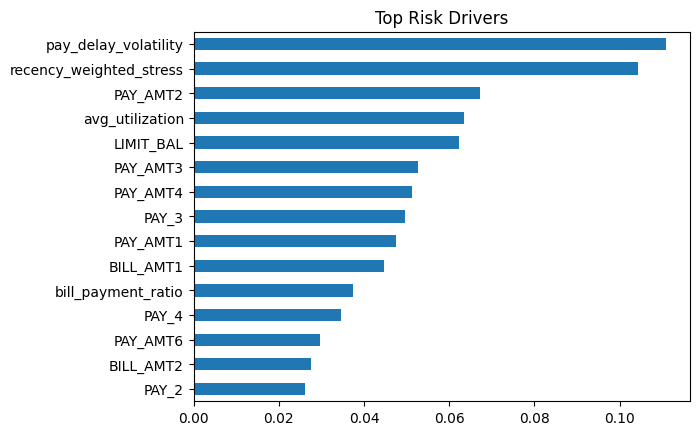

In [ ]:
import matplotlib.pyplot as plt

feature_importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Risk Drivers")
plt.show()

Customers exhibiting increasing instability in repayment behavior — measured through volatility and worsening trends — show significantly higher default risk.

This suggests early financial stress manifests as behavioral inconsistency before outright delinquency, enabling earlier intervention.

In [ ]:
val_results = X_val.copy()
val_results['true_default'] = y_val.values
val_results['log_pred_prob'] = log_val_probs
val_results['rf_pred_prob'] = rf_val_probs

save_path = "/content/drive/MyDrive/Credit_Risk_Project/data/validation_predictions.csv"
val_results.to_csv(save_path, index=False)

print("Saved validation predictions to:", save_path)


Saved validation predictions to: /content/drive/MyDrive/Credit_Risk_Project/data/validation_predictions.csv


In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/Credit_Risk_Project/models",
    exist_ok=True
)

print("Models folder created.")

Models folder created.


In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "/content/drive/MyDrive/Credit_Risk_Project/models/xgb_model.pkl"
)

['/content/drive/MyDrive/Credit_Risk_Project/models/xgb_model.pkl']

In [ ]:
os.listdir(
    "/content/drive/MyDrive/Credit_Risk_Project/models"
)

['xgb_model.pkl']